# Extended Data Fig. 27b - Optically derived 2D vs 3D regional density correlation (WT, 5 months)

Optically derived 2D sections from n=4 WT mice (5 months) are sampled by Protocol 1 (random coronal sections; here 5 sections) and Protocol 2 (uniform interval; here 150 um), and the resulting 2D-estimated regional densities are correlated against the 3D reference densities across 671 brain regions, separately for neurons (NeuN+), microglia (Iba1+) and non-neuronal cells. Axes are log-scaled; Spearman correlation is reported.

> Figures preserved from the original run; Japanese stripped from comments; verbose logs removed.

## Input files

| File | Content |
|---|---|
| optically-derived per-section regional densities (WT 5m, n=4) | 2D estimates |
| 3D whole-brain reference regional densities (WT 5m) | 3D reference (671 regions) |

## Protocol 1 (5 sections): 2D vs 3D regional density, by cell type

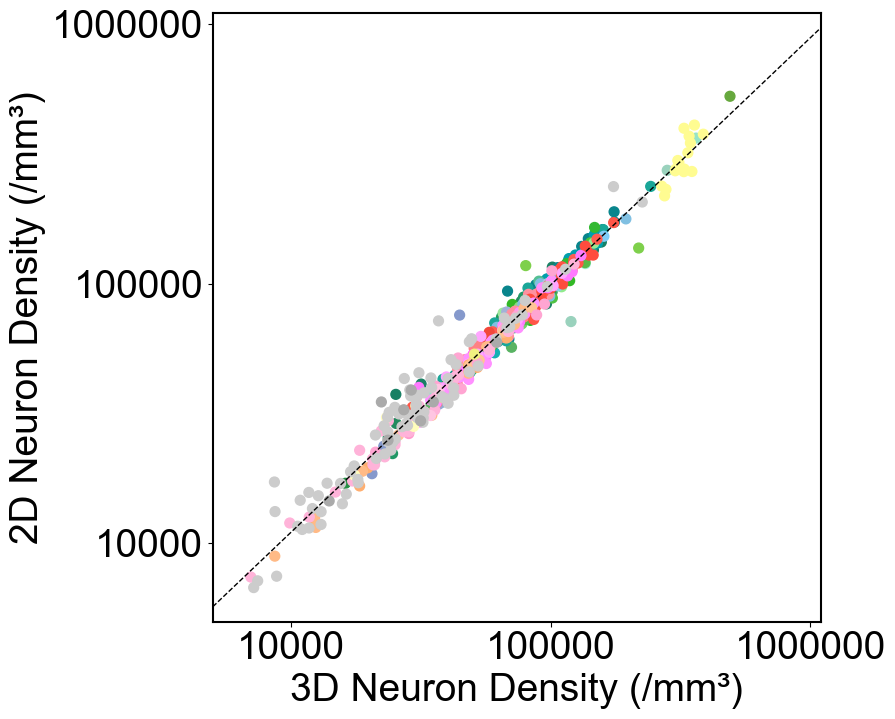

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import os
import matplotlib.ticker as mticker

#
GROUP_TO_ANALYZE = "WT_5m"
TARGET_CELL_TYPE = "neun"
SLICE_NUM_TO_CALCULATE = 5

#
DATA_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
#
COLOR_MAP_PATH = "/export3/Imaging/atlas_for_fig/GOvsID_6region_removed.csv" 

#
if __name__ == "__main__":
    #

    all_atlas_ids = data_GO['id'].unique().tolist()

    #
    input_filename = os.path.join(
        DATA_PATH,
        f"mean_3d_vs_2d_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}_{SLICE_NUM_TO_CALCULATE}slices.csv"
    )

    try:
        df = pd.read_csv(input_filename, index_col='region_id')
    except FileNotFoundError:
        print(f"ERROR: Input file not found at {input_filename}")
        exit()

    #
    df = df.reindex(all_atlas_ids, fill_value=0)
    #
    df = df.fillna(0) 

    #
    if not df.empty:
        corr, p_value = spearmanr(df['3d_mean'], df['2d_mean'])
        print(f"\nSpearman Correlation (including zeros): {corr:.4f}")
        print(f"P-value: {p_value:.4g}")
    else:
        print("\nCould not calculate correlation because the dataframe is empty.")

    #
    #
    df_for_plot = df[(df['3d_mean'] > 0) & (df['2d_mean'] > 0)].copy()
    print(f"\nTotal regions in data: {len(df)}. Regions for plotting (non-zero): {len(df_for_plot)}")
    #

    #
    try:
        color_df = pd.read_csv(COLOR_MAP_PATH)
        color_df = color_df[['id', 'R', 'G', 'B']]
        color_df['color'] = color_df.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)
        df_for_plot = df_for_plot.merge(color_df[['id', 'color']], left_index=True, right_on='id', how='left')
        df_for_plot['color'] = df_for_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)
        print("Successfully merged color map.")
        
    except FileNotFoundError:
        print(f"WARNING: Color map file not found at {COLOR_MAP_PATH}. All points will be blue.")
        df_for_plot['color'] = 'royalblue'

    if df_for_plot.empty:
        print("ERROR: The dataframe for plotting is empty after filtering for non-zero values. Cannot plot.")
        #
        # exit()

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    min_val_axis = 5000 
    max_val_axis = 1000000 * 1.1

    if not df_for_plot.empty:
        ax.scatter(
            df_for_plot['3d_mean'],
            df_for_plot['2d_mean'],
            alpha=1,
            s=50,
            c=df_for_plot['color']
        )
        
        log_3d = np.log10(df_for_plot['3d_mean'])
        log_2d = np.log10(df_for_plot['2d_mean'])
        m, c = np.polyfit(log_3d, log_2d, 1)
        
        x_fit = np.array([min_val_axis, max_val_axis])
        y_fit = 10**(m * np.log10(x_fit) + c)
        
        ax.plot(x_fit, y_fit, color='black', linewidth=1, linestyle='--')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('3D Neuron Density (/mm³)', fontsize=28)
    ax.set_ylabel('2D Neuron Density (/mm³)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.set_xlim(min_val_axis, max_val_axis)
    ax.set_ylim(min_val_axis, max_val_axis)
    ax.set_aspect('equal', adjustable='box')
    
    major_ticks = [10000, 100000, 1000000]
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(mticker.ScalarFormatter())
        axis.get_major_formatter().set_scientific(False)
        axis.set_minor_locator(mticker.NullLocator())

    plt.tight_layout()
    
    #
    #
    #
    output_filename_base = f"correlation_3d_vs_2d_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}_{SLICE_NUM_TO_CALCULATE}slices"
    
    #
    csv_output_filename = os.path.join(DATA_PATH, f"{output_filename_base}_colored_loglog.csv")
    df.to_csv(csv_output_filename, index_label='region_id')
    print(f"\nComplete DataFrame (all regions) saved to: {csv_output_filename}")

    #
    pdf_output_filename = os.path.join(DATA_PATH, f"{output_filename_base}_colored_loglog.pdf")
    plt.savefig(pdf_output_filename, transparent=True, dpi=300)
    print(f"Plot saved to: {pdf_output_filename}")
    plt.show()
    #


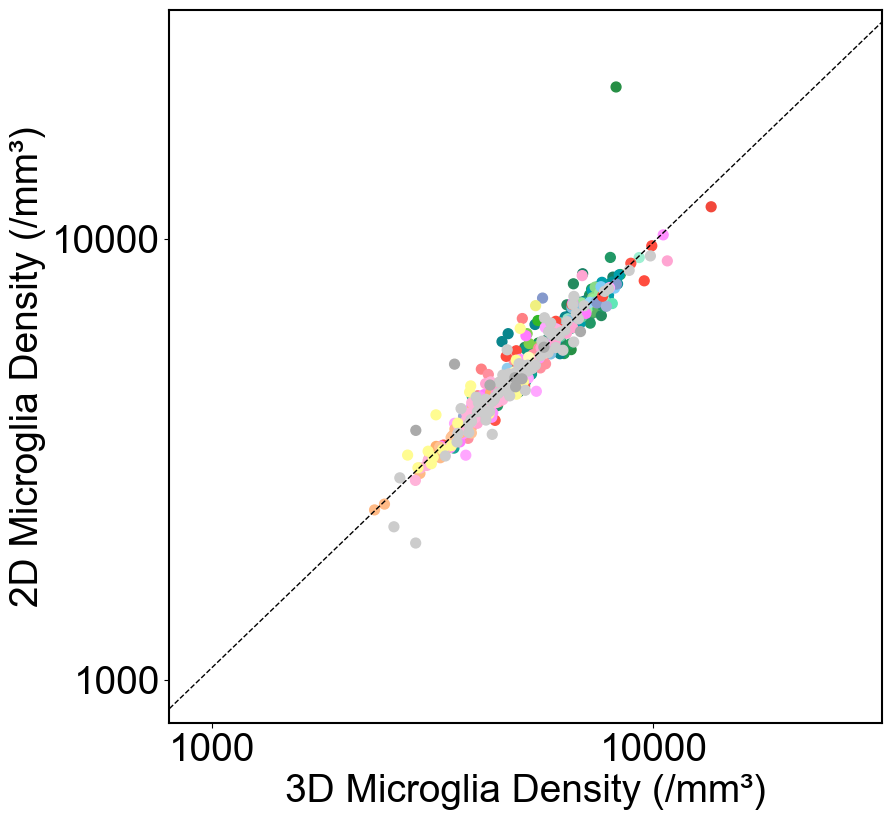

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import os
import matplotlib.ticker as mticker

#
GROUP_TO_ANALYZE = "WT_5m"
TARGET_CELL_TYPE = "iba1"
SLICE_NUM_TO_CALCULATE = 5

#
DATA_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
#
COLOR_MAP_PATH = "/export3/Imaging/atlas_for_fig/GOvsID_6region_removed.csv" 

#
if __name__ == "__main__":
    #

    all_atlas_ids = data_GO['id'].unique().tolist()

    #
    input_filename = os.path.join(
        DATA_PATH,
        f"mean_3d_vs_2d_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}_{SLICE_NUM_TO_CALCULATE}slices.csv"
    )

    try:
        df = pd.read_csv(input_filename, index_col='region_id')
    except FileNotFoundError:
        print(f"ERROR: Input file not found at {input_filename}")
        exit()

    #
    df = df.reindex(all_atlas_ids, fill_value=0)
    #
    df = df.fillna(0) 

    #
    if not df.empty:
        corr, p_value = spearmanr(df['3d_mean'], df['2d_mean'])
        print(f"\nSpearman Correlation (including zeros): {corr:.4f}")
        print(f"P-value: {p_value:.4g}")
    else:
        print("\nCould not calculate correlation because the dataframe is empty.")

    #
    #
    df_for_plot = df[(df['3d_mean'] > 0) & (df['2d_mean'] > 0)].copy()
    print(f"\nTotal regions in data: {len(df)}. Regions for plotting (non-zero): {len(df_for_plot)}")
    #

    #
    try:
        color_df = pd.read_csv(COLOR_MAP_PATH)
        color_df = color_df[['id', 'R', 'G', 'B']]
        color_df['color'] = color_df.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)
        df_for_plot = df_for_plot.merge(color_df[['id', 'color']], left_index=True, right_on='id', how='left')
        df_for_plot['color'] = df_for_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)
        print("Successfully merged color map.")
        
    except FileNotFoundError:
        print(f"WARNING: Color map file not found at {COLOR_MAP_PATH}. All points will be blue.")
        df_for_plot['color'] = 'royalblue'

    if df_for_plot.empty:
        print("ERROR: The dataframe for plotting is empty after filtering for non-zero values. Cannot plot.")
        #
        # exit()

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    min_val_axis = 800 
    max_val_axis = 30000 * 1.1

    if not df_for_plot.empty:
        ax.scatter(
            df_for_plot['3d_mean'],
            df_for_plot['2d_mean'],
            alpha=1,
            s=50,
            c=df_for_plot['color']
        )
        
        log_3d = np.log10(df_for_plot['3d_mean'])
        log_2d = np.log10(df_for_plot['2d_mean'])
        m, c = np.polyfit(log_3d, log_2d, 1)
        
        x_fit = np.array([min_val_axis, max_val_axis])
        y_fit = 10**(m * np.log10(x_fit) + c)
        
        ax.plot(x_fit, y_fit, color='black', linewidth=1, linestyle='--')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('3D Microglia Density (/mm³)', fontsize=28)
    ax.set_ylabel('2D Microglia Density (/mm³)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.set_xlim(min_val_axis, max_val_axis)
    ax.set_ylim(min_val_axis, max_val_axis)
    ax.set_aspect('equal', adjustable='box')
    
    major_ticks = [1000, 10000, ]
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(mticker.ScalarFormatter())
        axis.get_major_formatter().set_scientific(False)
        axis.set_minor_locator(mticker.NullLocator())

    plt.tight_layout()
    
    #
    #
    #
    output_filename_base = f"correlation_3d_vs_2d_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}_{SLICE_NUM_TO_CALCULATE}slices"
    
    #
    csv_output_filename = os.path.join(DATA_PATH, f"{output_filename_base}_colored_loglog.csv")
    df.to_csv(csv_output_filename, index_label='region_id')
    print(f"\nComplete DataFrame (all regions) saved to: {csv_output_filename}")

    #
    pdf_output_filename = os.path.join(DATA_PATH, f"{output_filename_base}_colored_loglog.pdf")
    plt.savefig(pdf_output_filename, transparent=True, dpi=300)
    print(f"Plot saved to: {pdf_output_filename}")
    plt.show()
    #


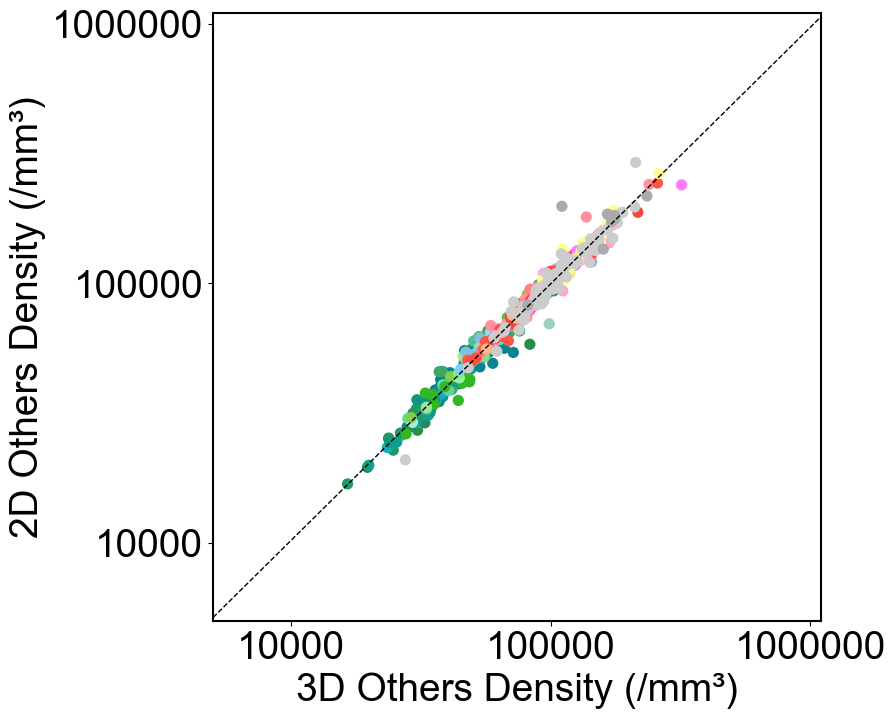

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import os
import matplotlib.ticker as mticker

#
GROUP_TO_ANALYZE = "WT_5m"
TARGET_CELL_TYPE = "others"
SLICE_NUM_TO_CALCULATE = 5

#
DATA_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
#
COLOR_MAP_PATH = "/export3/Imaging/atlas_for_fig/GOvsID_6region_removed.csv" 

#
if __name__ == "__main__":
    #

    all_atlas_ids = data_GO['id'].unique().tolist()

    #
    input_filename = os.path.join(
        DATA_PATH,
        f"mean_3d_vs_2d_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}_{SLICE_NUM_TO_CALCULATE}slices.csv"
    )

    try:
        df = pd.read_csv(input_filename, index_col='region_id')
    except FileNotFoundError:
        print(f"ERROR: Input file not found at {input_filename}")
        exit()

    #
    df = df.reindex(all_atlas_ids, fill_value=0)
    #
    df = df.fillna(0) 

    #
    if not df.empty:
        corr, p_value = spearmanr(df['3d_mean'], df['2d_mean'])
        print(f"\nSpearman Correlation (including zeros): {corr:.4f}")
        print(f"P-value: {p_value:.4g}")
    else:
        print("\nCould not calculate correlation because the dataframe is empty.")

    #
    #
    df_for_plot = df[(df['3d_mean'] > 0) & (df['2d_mean'] > 0)].copy()
    print(f"\nTotal regions in data: {len(df)}. Regions for plotting (non-zero): {len(df_for_plot)}")
    #

    #
    try:
        color_df = pd.read_csv(COLOR_MAP_PATH)
        color_df = color_df[['id', 'R', 'G', 'B']]
        color_df['color'] = color_df.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)
        df_for_plot = df_for_plot.merge(color_df[['id', 'color']], left_index=True, right_on='id', how='left')
        df_for_plot['color'] = df_for_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)
        print("Successfully merged color map.")
        
    except FileNotFoundError:
        print(f"WARNING: Color map file not found at {COLOR_MAP_PATH}. All points will be blue.")
        df_for_plot['color'] = 'royalblue'

    if df_for_plot.empty:
        print("ERROR: The dataframe for plotting is empty after filtering for non-zero values. Cannot plot.")
        #
        # exit()

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    min_val_axis = 5000 
    max_val_axis = 1000000 * 1.1

    if not df_for_plot.empty:
        ax.scatter(
            df_for_plot['3d_mean'],
            df_for_plot['2d_mean'],
            alpha=1,
            s=50,
            c=df_for_plot['color']
        )
        
        log_3d = np.log10(df_for_plot['3d_mean'])
        log_2d = np.log10(df_for_plot['2d_mean'])
        m, c = np.polyfit(log_3d, log_2d, 1)
        
        x_fit = np.array([min_val_axis, max_val_axis])
        y_fit = 10**(m * np.log10(x_fit) + c)
        
        ax.plot(x_fit, y_fit, color='black', linewidth=1, linestyle='--')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('3D Others Density (/mm³)', fontsize=28)
    ax.set_ylabel('2D Others Density (/mm³)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.set_xlim(min_val_axis, max_val_axis)
    ax.set_ylim(min_val_axis, max_val_axis)
    ax.set_aspect('equal', adjustable='box')
    
    major_ticks = [10000, 100000, 1000000]
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)

    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(mticker.ScalarFormatter())
        axis.get_major_formatter().set_scientific(False)
        axis.set_minor_locator(mticker.NullLocator())

    plt.tight_layout()
    
    #
    #
    #
    output_filename_base = f"correlation_3d_vs_2d_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}_{SLICE_NUM_TO_CALCULATE}slices"
    
    #
    csv_output_filename = os.path.join(DATA_PATH, f"{output_filename_base}_colored_loglog.csv")
    df.to_csv(csv_output_filename, index_label='region_id')
    print(f"\nComplete DataFrame (all regions) saved to: {csv_output_filename}")

    #
    pdf_output_filename = os.path.join(DATA_PATH, f"{output_filename_base}_colored_loglog.pdf")
    plt.savefig(pdf_output_filename, transparent=True, dpi=300)
    print(f"Plot saved to: {pdf_output_filename}")
    plt.show()
    #


## Protocol 2 (150 um interval): 2D vs 3D regional density, by cell type

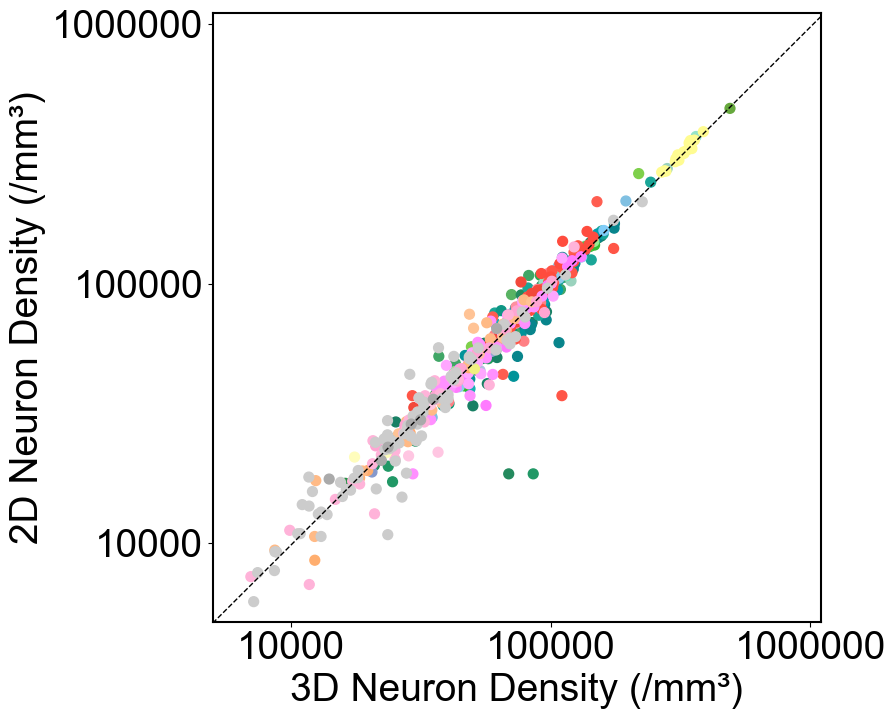

In [4]:
import os
import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import matplotlib.ticker as mticker
from tqdm import tqdm

#
GROUP_TO_ANALYZE = "WT_5m"
TARGET_CELL_TYPE = "neun" # 'neun', 'iba1', or 'others'
TARGET_COLUMN_3D = 'NeuN+ density (/mm3)' # 3D 

#
GRID_SIZE_UM = 30
SPAN_XY_UM = 150
SPAN_Z_UM = 150

#
DATA_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
COLOR_MAP_PATH = "/export3/Imaging/atlas_for_fig/GOvsID_6region_removed.csv" 

#

def get_base_dir(sample_id):
    """ ID """
    try:
        param_path = f"/home/mitani/CUBIC-informatics/param/Neuronomics/{sample_id}/param_multichannel-rank.json"
        with open(param_path) as f:
            param = json.load(f)
        
        base_dir = param["dst_basedir"]
        
        if ("Neurology_project_data_archive" not in base_dir
                and re.search(r'/ds4_Data\d+/', base_dir)):
            base_dir = re.sub(
                r'(/ds4_Data\d+/)',
                r'\1Neurology_project_data_archive/',
                base_dir,
            )
            
        return base_dir
        
    except Exception as e:
        print(f"Could not get base_dir for {sample_id}: {e}")
        return None

def calculate_3d_mean(sample_ids, column_name):
    """3D """
    all_3d_series = []
    for sid in sample_ids:
        base_dir = get_base_dir(sid)
        if base_dir:
            filepath = os.path.join(base_dir, "Regional_cellome4.csv")
            try:
                df = pd.read_csv(filepath, index_col=0)
                series = df[column_name]
                series.name = sid
                all_3d_series.append(series)
            except Exception as e:
                print(f"Could not load 3D data for {sid}: {e}")
    if not all_3d_series:
        return pd.Series(dtype='float64')
    
    df_3d_all_samples = pd.concat(all_3d_series, axis=1)
    return df_3d_all_samples.mean(axis=1)

def calculate_stereology_mean(sample_ids, cell_type, all_atlas_ids):
    """ 2D """
    all_2d_series = []
    
    span_xy_grid = SPAN_XY_UM // GRID_SIZE_UM
    span_z_grid = SPAN_Z_UM // GRID_SIZE_UM

    for sid in tqdm(sample_ids, desc=f"Stereology Sim for {GROUP_TO_ANALYZE}"):
        base_dir = get_base_dir(sid)
        if not base_dir: continue
        
        grid_file = os.path.join(base_dir, "cell_counts_per_30um_grid_ver2_2.csv.gz")
        try:
            df_grid = pd.read_csv(grid_file)
            df_grid = df_grid[df_grid['cell_type'] == cell_type]

            min_x, max_x = df_grid['grid_x'].min(), df_grid['grid_x'].max()
            min_y, max_y = df_grid['grid_y'].min(), df_grid['grid_y'].max()
            min_z, max_z = df_grid['grid_z'].min(), df_grid['grid_z'].max()
            offset_x, offset_y, offset_z = np.random.randint(0, [span_xy_grid, span_xy_grid, span_z_grid])

            sampled_x = np.arange(min_x + offset_x, max_x + 1, span_xy_grid)
            sampled_y = np.arange(min_y + offset_y, max_y + 1, span_xy_grid)
            sampled_z = np.arange(min_z + offset_z, max_z + 1, span_z_grid)

            hits = df_grid[
                df_grid['grid_x'].isin(sampled_x) &
                df_grid['grid_y'].isin(sampled_y) &
                df_grid['grid_z'].isin(sampled_z)
            ]
            
            total_cells = hits.groupby('atlas_id')['count'].sum()
            total_grids = hits.groupby('atlas_id').size()
            
            grid_volume_mm3 = (GRID_SIZE_UM * 0.001) ** 3
            density = total_cells / (total_grids * grid_volume_mm3)
            
            density = density.reindex(all_atlas_ids, fill_value=0)
            
            density.name = sid
            all_2d_series.append(density)

        except Exception as e:
            print(f"Could not process stereology for {sid}: {e}")

    if not all_2d_series:
        return pd.Series(dtype='float64')
        
    df_2d_all_samples = pd.concat(all_2d_series, axis=1)
    return df_2d_all_samples.mean(axis=1)

#
if __name__ == "__main__":

    sample_ids = conditions.get(GROUP_TO_ANALYZE)
    if not sample_ids:
        print(f"ERROR: No samples defined for group '{GROUP_TO_ANALYZE}'.")
        exit()

    all_atlas_ids = data_GO['id'].unique().tolist()
    

    #
    print("--- Calculating 3D Mean Density (Ground Truth) ---")
    s_3d_mean = calculate_3d_mean(sample_ids, TARGET_COLUMN_3D)
    
    print("\n--- Calculating 2D Estimated Mean Density (Stereology) ---")
    s_2d_mean = calculate_stereology_mean(sample_ids, TARGET_CELL_TYPE, all_atlas_ids)

    #
    df = pd.DataFrame({'3d_mean': s_3d_mean, '2d_mean': s_2d_mean})
    df = df.fillna(0)
    
    #
    #
    if not df.empty:
        corr, p_value = spearmanr(df['3d_mean'], df['2d_mean'])
        print(f"\nSpearman Correlation (including zeros): {corr:.4f}, P-value: {p_value:.4g}")
    else:
        print("\nCould not calculate correlation because the dataframe is empty.")

    #
    #
    df_for_plot = df[(df['3d_mean'] > 0) & (df['2d_mean'] > 0)].copy()

    #
    try:
        color_df = pd.read_csv(COLOR_MAP_PATH)
        color_df = color_df[['id', 'R', 'G', 'B']]
        color_df['color'] = color_df.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)
        df_for_plot = df_for_plot.merge(color_df[['id', 'color']], left_index=True, right_on='id', how='left')
        df_for_plot['color'] = df_for_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)
    except FileNotFoundError:
        print(f"WARNING: Color map file not found at {COLOR_MAP_PATH}. Using default color.")
        df_for_plot['color'] = 'royalblue'
    #

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    if not df_for_plot.empty:
        ax.scatter(
            df_for_plot['3d_mean'],
            df_for_plot['2d_mean'],
            alpha=1,
            s=50,
            c=df_for_plot['color']
        )
        
        log_3d = np.log10(df_for_plot['3d_mean'])
        log_2d = np.log10(df_for_plot['2d_mean'])
        m, c = np.polyfit(log_3d, log_2d, 1)
        
        min_val_axis = 5000
        max_val_axis = 1000000 * 1.1
        
        x_fit = np.array([min_val_axis, max_val_axis])
        y_fit = 10**(m * np.log10(x_fit) + c)
        ax.plot(x_fit, y_fit, color='black', linewidth=1, linestyle='--')
    else:
        min_val_axis = 5000
        max_val_axis = 1000000 * 1.1

    #
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('3D Neuron Density (/mm³)', fontsize=28)
    ax.set_ylabel('2D Neuron Density (/mm³)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.set_xlim(min_val_axis, max_val_axis)
    ax.set_ylim(min_val_axis, max_val_axis)
    ax.set_aspect('equal', adjustable='box')
    major_ticks = [10000, 100000, 1000000]
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(mticker.ScalarFormatter())
        axis.get_major_formatter().set_scientific(False)
        axis.set_minor_locator(mticker.NullLocator())
    plt.tight_layout()
    
    #
    csv_output_filename = os.path.join(
        DATA_PATH,
        f"correlation_3d_vs_2d_stereology_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}.csv"
    )
    #
    df.to_csv(csv_output_filename)
    print(f"\nDataFrame saved to: {csv_output_filename}")

    pdf_output_filename = os.path.join(
        DATA_PATH,
        f"correlation_3d_vs_2d_stereology_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}.pdf"
    )
    plt.savefig(pdf_output_filename, transparent=True, dpi=300)
    print(f"Plot saved to: {pdf_output_filename}")
    plt.show()

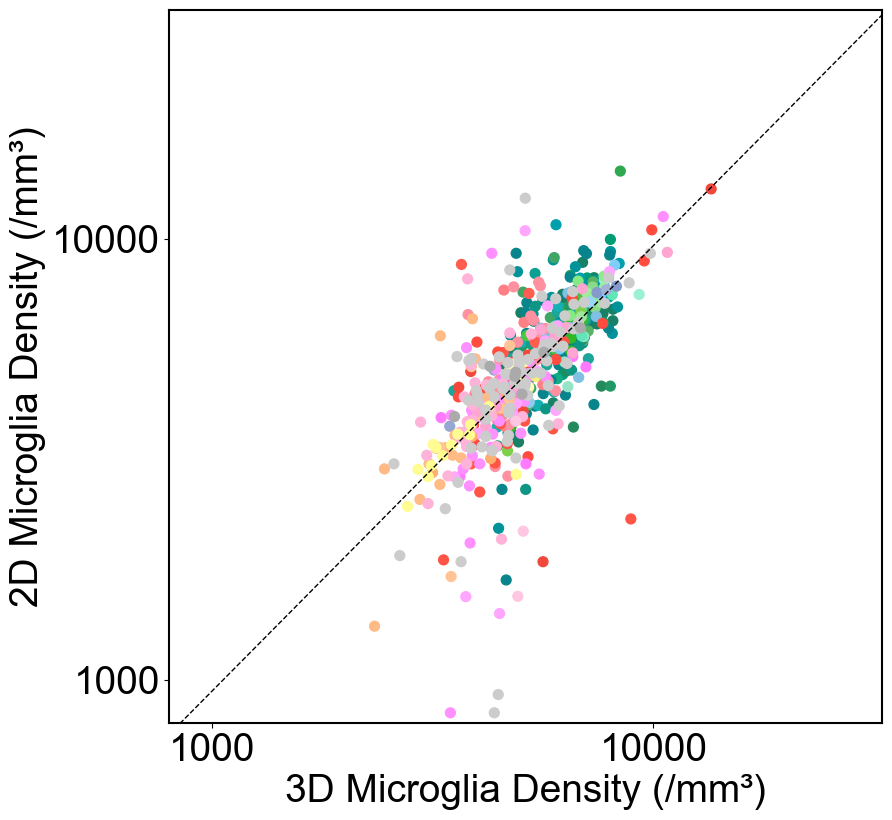

In [5]:
import os
import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import matplotlib.ticker as mticker
from tqdm import tqdm

#
GROUP_TO_ANALYZE = "WT_5m"
TARGET_CELL_TYPE = "iba1" # 'neun', 'iba1', or 'others'
TARGET_COLUMN_3D = 'Iba1+ density (/mm3)' # 3D 

#
GRID_SIZE_UM = 30
SPAN_XY_UM = 150
SPAN_Z_UM = 150

#
DATA_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
COLOR_MAP_PATH = "/export3/Imaging/atlas_for_fig/GOvsID_6region_removed.csv" 

#

def get_base_dir(sample_id):
    """ ID """
    try:
        param_path = f"/home/mitani/CUBIC-informatics/param/Neuronomics/{sample_id}/param_multichannel-rank.json"
        with open(param_path) as f:
            param = json.load(f)
        
        base_dir = param["dst_basedir"]
        
        if ("Neurology_project_data_archive" not in base_dir
                and re.search(r'/ds4_Data\d+/', base_dir)):
            base_dir = re.sub(
                r'(/ds4_Data\d+/)',
                r'\1Neurology_project_data_archive/',
                base_dir,
            )
            
        return base_dir
        
    except Exception as e:
        print(f"Could not get base_dir for {sample_id}: {e}")
        return None

def calculate_3d_mean(sample_ids, column_name):
    """3D """
    all_3d_series = []
    for sid in sample_ids:
        base_dir = get_base_dir(sid)
        if base_dir:
            filepath = os.path.join(base_dir, "Regional_cellome4.csv")
            try:
                df = pd.read_csv(filepath, index_col=0)
                series = df[column_name]
                series.name = sid
                all_3d_series.append(series)
            except Exception as e:
                print(f"Could not load 3D data for {sid}: {e}")
    if not all_3d_series:
        return pd.Series(dtype='float64')
    
    df_3d_all_samples = pd.concat(all_3d_series, axis=1)
    return df_3d_all_samples.mean(axis=1)

def calculate_stereology_mean(sample_ids, cell_type, all_atlas_ids):
    """ 2D """
    all_2d_series = []
    
    span_xy_grid = SPAN_XY_UM // GRID_SIZE_UM
    span_z_grid = SPAN_Z_UM // GRID_SIZE_UM

    for sid in tqdm(sample_ids, desc=f"Stereology Sim for {GROUP_TO_ANALYZE}"):
        base_dir = get_base_dir(sid)
        if not base_dir: continue
        
        grid_file = os.path.join(base_dir, "cell_counts_per_30um_grid_ver2_2.csv.gz")
        try:
            df_grid = pd.read_csv(grid_file)
            df_grid = df_grid[df_grid['cell_type'] == cell_type]

            min_x, max_x = df_grid['grid_x'].min(), df_grid['grid_x'].max()
            min_y, max_y = df_grid['grid_y'].min(), df_grid['grid_y'].max()
            min_z, max_z = df_grid['grid_z'].min(), df_grid['grid_z'].max()
            offset_x, offset_y, offset_z = np.random.randint(0, [span_xy_grid, span_xy_grid, span_z_grid])

            sampled_x = np.arange(min_x + offset_x, max_x + 1, span_xy_grid)
            sampled_y = np.arange(min_y + offset_y, max_y + 1, span_xy_grid)
            sampled_z = np.arange(min_z + offset_z, max_z + 1, span_z_grid)

            hits = df_grid[
                df_grid['grid_x'].isin(sampled_x) &
                df_grid['grid_y'].isin(sampled_y) &
                df_grid['grid_z'].isin(sampled_z)
            ]
            
            total_cells = hits.groupby('atlas_id')['count'].sum()
            total_grids = hits.groupby('atlas_id').size()
            
            grid_volume_mm3 = (GRID_SIZE_UM * 0.001) ** 3
            density = total_cells / (total_grids * grid_volume_mm3)
            
            density = density.reindex(all_atlas_ids, fill_value=0)
            
            density.name = sid
            all_2d_series.append(density)

        except Exception as e:
            print(f"Could not process stereology for {sid}: {e}")

    if not all_2d_series:
        return pd.Series(dtype='float64')
        
    df_2d_all_samples = pd.concat(all_2d_series, axis=1)
    return df_2d_all_samples.mean(axis=1)

#
if __name__ == "__main__":

    sample_ids = conditions.get(GROUP_TO_ANALYZE)
    if not sample_ids:
        print(f"ERROR: No samples defined for group '{GROUP_TO_ANALYZE}'.")
        exit()

    all_atlas_ids = data_GO['id'].unique().tolist()
    

    #
    print("--- Calculating 3D Mean Density (Ground Truth) ---")
    s_3d_mean = calculate_3d_mean(sample_ids, TARGET_COLUMN_3D)
    
    print("\n--- Calculating 2D Estimated Mean Density (Stereology) ---")
    s_2d_mean = calculate_stereology_mean(sample_ids, TARGET_CELL_TYPE, all_atlas_ids)

    #
    df = pd.DataFrame({'3d_mean': s_3d_mean, '2d_mean': s_2d_mean})
    df = df.fillna(0)
    
    #
    #
    if not df.empty:
        corr, p_value = spearmanr(df['3d_mean'], df['2d_mean'])
        print(f"\nSpearman Correlation (including zeros): {corr:.4f}, P-value: {p_value:.4g}")
    else:
        print("\nCould not calculate correlation because the dataframe is empty.")

    #
    #
    df_for_plot = df[(df['3d_mean'] > 0) & (df['2d_mean'] > 0)].copy()

    #
    try:
        color_df = pd.read_csv(COLOR_MAP_PATH)
        color_df = color_df[['id', 'R', 'G', 'B']]
        color_df['color'] = color_df.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)
        df_for_plot = df_for_plot.merge(color_df[['id', 'color']], left_index=True, right_on='id', how='left')
        df_for_plot['color'] = df_for_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)
    except FileNotFoundError:
        print(f"WARNING: Color map file not found at {COLOR_MAP_PATH}. Using default color.")
        df_for_plot['color'] = 'royalblue'
    #

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    if not df_for_plot.empty:
        ax.scatter(
            df_for_plot['3d_mean'],
            df_for_plot['2d_mean'],
            alpha=1,
            s=50,
            c=df_for_plot['color']
        )
        
        log_3d = np.log10(df_for_plot['3d_mean'])
        log_2d = np.log10(df_for_plot['2d_mean'])
        m, c = np.polyfit(log_3d, log_2d, 1)
        
        min_val_axis = 800 
        max_val_axis = 30000 * 1.1
        
        x_fit = np.array([min_val_axis, max_val_axis])
        y_fit = 10**(m * np.log10(x_fit) + c)
        ax.plot(x_fit, y_fit, color='black', linewidth=1, linestyle='--')
    else:
        min_val_axis = 800 
        max_val_axis = 30000 * 1.1

    #
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('3D Microglia Density (/mm³)', fontsize=28)
    ax.set_ylabel('2D Microglia Density (/mm³)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.set_xlim(min_val_axis, max_val_axis)
    ax.set_ylim(min_val_axis, max_val_axis)
    ax.set_aspect('equal', adjustable='box')
    major_ticks = [1000, 10000, ]
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(mticker.ScalarFormatter())
        axis.get_major_formatter().set_scientific(False)
        axis.set_minor_locator(mticker.NullLocator())
    plt.tight_layout()
    
    #
    csv_output_filename = os.path.join(
        DATA_PATH,
        f"correlation_3d_vs_2d_stereology_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}.csv"
    )
    #
    df.to_csv(csv_output_filename)
    print(f"\nDataFrame saved to: {csv_output_filename}")

    pdf_output_filename = os.path.join(
        DATA_PATH,
        f"correlation_3d_vs_2d_stereology_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}.pdf"
    )
    plt.savefig(pdf_output_filename, transparent=True, dpi=300)
    print(f"Plot saved to: {pdf_output_filename}")
    plt.show()

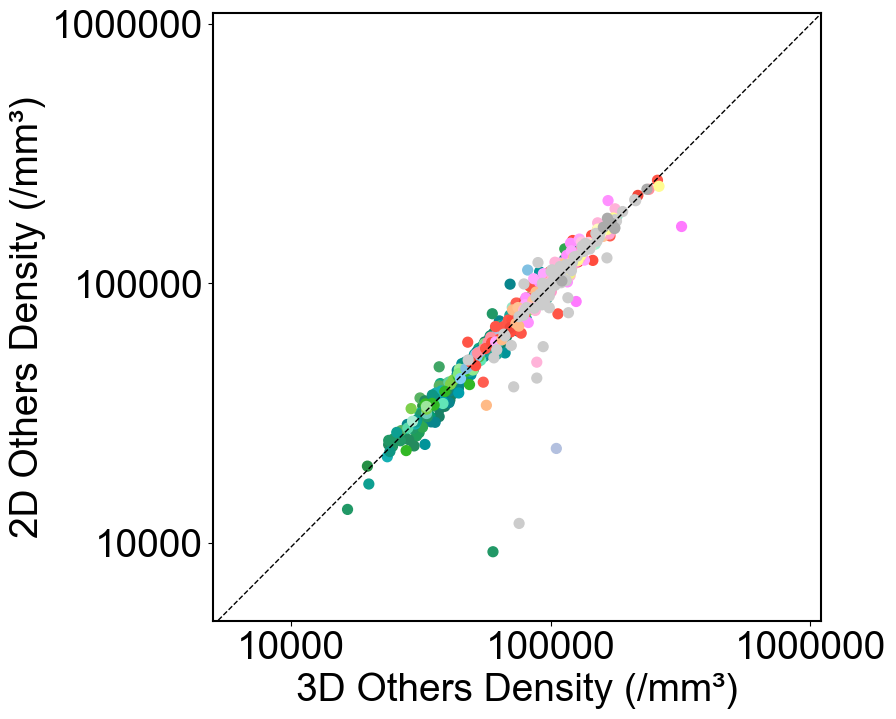

In [6]:
import os
import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from scipy.stats import spearmanr
import matplotlib.ticker as mticker
from tqdm import tqdm

#
GROUP_TO_ANALYZE = "WT_5m"
TARGET_CELL_TYPE = "others" # 'neun', 'iba1', or 'others'
TARGET_COLUMN_3D = 'Others+ density (/mm3)' # 3D 

#
GRID_SIZE_UM = 30
SPAN_XY_UM = 150
SPAN_Z_UM = 150

#
DATA_PATH = "/export3/Imaging/ds4_Data5/Neurology_project_data_archive/mitani/Neurology/Rebuttal Figures/"
COLOR_MAP_PATH = "/export3/Imaging/atlas_for_fig/GOvsID_6region_removed.csv" 

#

def get_base_dir(sample_id):
    """ ID """
    try:
        param_path = f"/home/mitani/CUBIC-informatics/param/Neuronomics/{sample_id}/param_multichannel-rank.json"
        with open(param_path) as f:
            param = json.load(f)
        
        base_dir = param["dst_basedir"]
        
        if ("Neurology_project_data_archive" not in base_dir
                and re.search(r'/ds4_Data\d+/', base_dir)):
            base_dir = re.sub(
                r'(/ds4_Data\d+/)',
                r'\1Neurology_project_data_archive/',
                base_dir,
            )
            
        return base_dir
        
    except Exception as e:
        print(f"Could not get base_dir for {sample_id}: {e}")
        return None

def calculate_3d_mean(sample_ids, column_name):
    """3D """
    all_3d_series = []
    for sid in sample_ids:
        base_dir = get_base_dir(sid)
        if base_dir:
            filepath = os.path.join(base_dir, "Regional_cellome4.csv")
            try:
                df = pd.read_csv(filepath, index_col=0)
                series = df[column_name]
                series.name = sid
                all_3d_series.append(series)
            except Exception as e:
                print(f"Could not load 3D data for {sid}: {e}")
    if not all_3d_series:
        return pd.Series(dtype='float64')
    
    df_3d_all_samples = pd.concat(all_3d_series, axis=1)
    return df_3d_all_samples.mean(axis=1)

def calculate_stereology_mean(sample_ids, cell_type, all_atlas_ids):
    """ 2D """
    all_2d_series = []
    
    span_xy_grid = SPAN_XY_UM // GRID_SIZE_UM
    span_z_grid = SPAN_Z_UM // GRID_SIZE_UM

    for sid in tqdm(sample_ids, desc=f"Stereology Sim for {GROUP_TO_ANALYZE}"):
        base_dir = get_base_dir(sid)
        if not base_dir: continue
        
        grid_file = os.path.join(base_dir, "cell_counts_per_30um_grid_ver2_2.csv.gz")
        try:
            df_grid = pd.read_csv(grid_file)
            df_grid = df_grid[df_grid['cell_type'] == cell_type]

            min_x, max_x = df_grid['grid_x'].min(), df_grid['grid_x'].max()
            min_y, max_y = df_grid['grid_y'].min(), df_grid['grid_y'].max()
            min_z, max_z = df_grid['grid_z'].min(), df_grid['grid_z'].max()
            offset_x, offset_y, offset_z = np.random.randint(0, [span_xy_grid, span_xy_grid, span_z_grid])

            sampled_x = np.arange(min_x + offset_x, max_x + 1, span_xy_grid)
            sampled_y = np.arange(min_y + offset_y, max_y + 1, span_xy_grid)
            sampled_z = np.arange(min_z + offset_z, max_z + 1, span_z_grid)

            hits = df_grid[
                df_grid['grid_x'].isin(sampled_x) &
                df_grid['grid_y'].isin(sampled_y) &
                df_grid['grid_z'].isin(sampled_z)
            ]
            
            total_cells = hits.groupby('atlas_id')['count'].sum()
            total_grids = hits.groupby('atlas_id').size()
            
            grid_volume_mm3 = (GRID_SIZE_UM * 0.001) ** 3
            density = total_cells / (total_grids * grid_volume_mm3)
            
            density = density.reindex(all_atlas_ids, fill_value=0)
            
            density.name = sid
            all_2d_series.append(density)

        except Exception as e:
            print(f"Could not process stereology for {sid}: {e}")

    if not all_2d_series:
        return pd.Series(dtype='float64')
        
    df_2d_all_samples = pd.concat(all_2d_series, axis=1)
    return df_2d_all_samples.mean(axis=1)

#
if __name__ == "__main__":

    sample_ids = conditions.get(GROUP_TO_ANALYZE)
    if not sample_ids:
        print(f"ERROR: No samples defined for group '{GROUP_TO_ANALYZE}'.")
        exit()

    all_atlas_ids = data_GO['id'].unique().tolist()
    

    #
    print("--- Calculating 3D Mean Density (Ground Truth) ---")
    s_3d_mean = calculate_3d_mean(sample_ids, TARGET_COLUMN_3D)
    
    print("\n--- Calculating 2D Estimated Mean Density (Stereology) ---")
    s_2d_mean = calculate_stereology_mean(sample_ids, TARGET_CELL_TYPE, all_atlas_ids)

    #
    df = pd.DataFrame({'3d_mean': s_3d_mean, '2d_mean': s_2d_mean})
    df = df.fillna(0)
    
    #
    #
    if not df.empty:
        corr, p_value = spearmanr(df['3d_mean'], df['2d_mean'])
        print(f"\nSpearman Correlation (including zeros): {corr:.4f}, P-value: {p_value:.4g}")
    else:
        print("\nCould not calculate correlation because the dataframe is empty.")

    #
    #
    df_for_plot = df[(df['3d_mean'] > 0) & (df['2d_mean'] > 0)].copy()

    #
    try:
        color_df = pd.read_csv(COLOR_MAP_PATH)
        color_df = color_df[['id', 'R', 'G', 'B']]
        color_df['color'] = color_df.apply(lambda row: (row['R']/255, row['G']/255, row['B']/255), axis=1)
        df_for_plot = df_for_plot.merge(color_df[['id', 'color']], left_index=True, right_on='id', how='left')
        df_for_plot['color'] = df_for_plot['color'].apply(lambda x: (0.7, 0.7, 0.7) if pd.isnull(x) else x)
    except FileNotFoundError:
        print(f"WARNING: Color map file not found at {COLOR_MAP_PATH}. Using default color.")
        df_for_plot['color'] = 'royalblue'
    #

    #
    plt.style.use('default')
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['font.family'] = 'Arial'
    matplotlib.rcParams['axes.linewidth'] = 1.5
    fig, ax = plt.subplots(figsize=(9, 9))

    if not df_for_plot.empty:
        ax.scatter(
            df_for_plot['3d_mean'],
            df_for_plot['2d_mean'],
            alpha=1,
            s=50,
            c=df_for_plot['color']
        )
        
        log_3d = np.log10(df_for_plot['3d_mean'])
        log_2d = np.log10(df_for_plot['2d_mean'])
        m, c = np.polyfit(log_3d, log_2d, 1)
        
        min_val_axis = 5000
        max_val_axis = 1000000 * 1.1
        
        x_fit = np.array([min_val_axis, max_val_axis])
        y_fit = 10**(m * np.log10(x_fit) + c)
        ax.plot(x_fit, y_fit, color='black', linewidth=1, linestyle='--')
    else:
        min_val_axis = 5000
        max_val_axis = 1000000 * 1.1

    #
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('3D Others Density (/mm³)', fontsize=28)
    ax.set_ylabel('2D Others Density (/mm³)', fontsize=28)
    ax.tick_params(axis='both', which='major', labelsize=28)
    ax.set_xlim(min_val_axis, max_val_axis)
    ax.set_ylim(min_val_axis, max_val_axis)
    ax.set_aspect('equal', adjustable='box')
    major_ticks = [10000, 100000, 1000000]
    ax.set_xticks(major_ticks)
    ax.set_yticks(major_ticks)
    for axis in [ax.xaxis, ax.yaxis]:
        axis.set_major_formatter(mticker.ScalarFormatter())
        axis.get_major_formatter().set_scientific(False)
        axis.set_minor_locator(mticker.NullLocator())
    plt.tight_layout()
    
    #
    csv_output_filename = os.path.join(
        DATA_PATH,
        f"correlation_3d_vs_2d_stereology_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}.csv"
    )
    #
    df.to_csv(csv_output_filename)
    print(f"\nDataFrame saved to: {csv_output_filename}")

    pdf_output_filename = os.path.join(
        DATA_PATH,
        f"correlation_3d_vs_2d_stereology_{GROUP_TO_ANALYZE}_{TARGET_CELL_TYPE}.pdf"
    )
    plt.savefig(pdf_output_filename, transparent=True, dpi=300)
    print(f"Plot saved to: {pdf_output_filename}")
    plt.show()